# Baseline Models

- M/M/c queue, where c is the number of servers.

Sources
- https://www.gao.gov/assets/gao-18-236.pdf
    - "average of 27% of passengers use TSA PreCheck"
- https://www.trb.org/publications/circulars/ec060/06_Bradley.pdf
    - The data is noisy and doesn't have exact data on number of TSA screeners, just staff
    - We make the assumption that half of the staff are TSA PreCheck screeners
    - This gives us an average of 4.5 TSA PreCheck screeners, with a range of 2 to 12 across a whole day. 

## Version 1

- This baseline model is an M/M/c queue, where c is the number of servers.
- The servers are shared between regular and TSA PreCheck passengers. Pooled servers.
- This is not parallel. There is no closed form solution for this model.

Distribution Assumptions

The interarrival times of the passengers are exponentially distributed with a mean of $\frac{1}{\lambda}$, where $\lambda$ is the arrival rate of passengers. The pdf is given by:

$$
a(t) = 
\begin{cases}
  \lambda e^{-\lambda t} & \text{if } t \geq 0 \\
  0 & \text{if } t < 0
\end{cases}
$$

Interarrival times can be interpreted as "how long do I wait until the next person arrives?".

As for the service times, we also assume they are exponentially distributed, where $\mu$ is the service rate of the servers. The mean service time is $\frac{1}{\mu}$. The pdf is given by:

$$
b(t) =
\begin{cases}
  \mu e^{-\mu t} & \text{if } t \geq 0 \\
  0 & \text{if } t < 0
\end{cases}
$$

Memoryless Property

The exponential distribution is the only continous distribution with the memoryless property. Other distributions in the exponential family do not have this property. This means that the probability of waiting an additional time $t$ is independent of how long you have already waited. 

$$
P(X > s + t | X > s) = P(X > t) \quad \forall s, t \geq 0
$$

In reality, this assumption is quite strong for service times because if service time has already been long, it is likely to be longer (i.e. dealing with a complex issue or unruly passenger). We'll relax this assumption later.


### Parameters Research

In [1239]:
import heapq
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [1240]:
# Parameters
# units are passengers per minute
ARRIVAL_RATE = 23.6

In [1241]:
ARRIVAL_RATE

23.6

- See modeling notebook for parameter calculations.
- Sensitivity analysis on this. Use range from model fitting notebook.

In [1242]:
# These are lower bounds
# Service rate for regular passengers, units are passengers per minute
SERVICE_RATE_REGULAR = 1.9701
# Faster service rate for TSA PreCheck
SERVICE_RATE_PRECHECK = 1.9701 * 1.33

In [1243]:
SERVICE_RATE_REGULAR

1.9701

In [1244]:
SERVICE_RATE_PRECHECK

2.6202330000000003

- For service rate, we make the simplifying assumption that it encompasses the process form id and boarding pass check to the end of the screening process where one picks up their bags at the end of the conveyor belt.
- Sources below provide an lower bound on service time. For regular it is 30 minutes per passenger, for TSA pre it's 19 minutes per passenger.
- TSA is quicker by 33%
- Sensitivity analysis on this. Keep the 1.33 factor.

Sources
- https://www.gao.gov/assets/gao-18-236.pdf

In [1245]:
PRECHECK_PROB = 0.27  # Probability of being PreCheck


Sources
- https://www.washingtonpost.com/travel/2024/11/28/tsa-precheck-vs-standard-security-line/
- https://www.yahoo.com/news/reached-peak-precheck-233857724.html

In [1246]:
NUM_SERVERS = 12

- Estimate from empirical data
- Sensivity analysis on this. Use range from lockheed martin data.

In [1247]:
# 33987.54375
MAX_CUST = 34000

- Estimate from data
- 33987.54375

### Simulation Functions

In [1248]:
def record_wait_time(
    wait_time, is_precheck, wait_times_precheck, wait_times_regular, cid
):
    """Record wait time in appropriate list"""
    if is_precheck:
        wait_times_precheck[cid] = wait_time
    else:
        wait_times_regular[cid] = wait_time

In [1249]:
def get_service_time(is_precheck, service_rate_precheck, service_rate_regular):
    """Generate service time based on customer type"""
    service_rate = service_rate_precheck if is_precheck else service_rate_regular
    return random.expovariate(service_rate)

In [1250]:
def find_available_servers(servers_busy_until, current_time):
    """Find all available servers"""
    return [i for i, t in enumerate(servers_busy_until) if t <= current_time]

In [1251]:
def assign_to_server_or_queue(
    servers_busy_until,
    current_time,
    is_precheck,
    service_rate_precheck,
    service_rate_regular,
    event_queue,
    cid,
    waiting_queue,
    priority,
    wait_times_precheck,
    wait_times_regular,
):
    """Assign customer to available server or add to waiting queue"""
    available_servers = find_available_servers(servers_busy_until, current_time)

    if available_servers:
        server = available_servers[0]
        service_time = get_service_time(
            is_precheck, service_rate_precheck, service_rate_regular
        )
        servers_busy_until[server] = current_time + service_time

        record_wait_time(0.0, is_precheck, wait_times_precheck, wait_times_regular, cid)

        heapq.heappush(event_queue, (current_time + service_time, "departure", cid))
    else:
        heapq.heappush(waiting_queue, (priority, current_time, cid, is_precheck))

In [1252]:
def handle_arrival_event(
    event_queue,
    current_time,
    cid,
    customer_id,
    arrival_rate,
    precheck_probability,
    servers_busy_until,
    service_rate_precheck,
    service_rate_regular,
    waiting_queue,
    wait_times_precheck,
    wait_times_regular,
    arrival_times_precheck,
    arrival_times_regular,
):
    """Process a customer arrival event"""

    # Schedule next arrival
    inter_arrival = random.expovariate(arrival_rate)
    heapq.heappush(event_queue, (current_time + inter_arrival, "arrival", customer_id))

    # Determine if PreCheck or regular
    is_precheck = random.random() < precheck_probability
    priority = 0 if is_precheck else 1

    # Record arrival time
    if is_precheck:
        arrival_times_precheck[cid] = current_time
    else:
        arrival_times_regular[cid] = current_time

    # Try to assign to server
    assign_to_server_or_queue(
        servers_busy_until,
        current_time,
        is_precheck,
        service_rate_precheck,
        service_rate_regular,
        event_queue,
        cid,
        waiting_queue,
        priority,
        wait_times_precheck,
        wait_times_regular,
    )

    return customer_id + 1

In [1253]:
def handle_departure_event(
    event_queue,
    current_time,
    servers_busy_until,
    waiting_queue,
    service_rate_precheck,
    service_rate_regular,
    wait_times_precheck,
    wait_times_regular,
):
    """Process a server departure event"""
    available_servers = find_available_servers(servers_busy_until, current_time)

    for server in available_servers:
        if waiting_queue:
            priority, arrival_time, queued_cid, is_precheck = heapq.heappop(
                waiting_queue
            )
            service_time = get_service_time(
                is_precheck, service_rate_precheck, service_rate_regular
            )
            servers_busy_until[server] = current_time + service_time

            wait_time = current_time - arrival_time
            record_wait_time(
                wait_time,
                is_precheck,
                wait_times_precheck,
                wait_times_regular,
                queued_cid,
            )

            heapq.heappush(
                event_queue, (current_time + service_time, "departure", queued_cid)
            )

In [1254]:
def run_simulation(
    max_cust,
    arrival_rate,
    precheck_probability,
    service_rate_precheck,
    service_rate_regular,
    num_servers,
):
    """Main simulation function"""
    # System State
    event_queue = []
    waiting_queue = []
    servers_busy_until = [0.0] * num_servers
    wait_times_precheck = dict()
    wait_times_regular = dict()

    # For plotting layer
    arrival_times_precheck = dict()
    arrival_times_regular = dict()

    # Schedule first arrival
    heapq.heappush(event_queue, (0.0, "arrival", 0))
    customer_id = 1

    # Main event loop
    while event_queue:
        event_time, event_type, cid = heapq.heappop(event_queue)
        current_time = event_time

        if event_type == "arrival":
            if customer_id <= MAX_CUST:
                # Handle arrival event
                customer_id = handle_arrival_event(
                    event_queue,
                    current_time,
                    cid,
                    customer_id,
                    arrival_rate,
                    precheck_probability,
                    servers_busy_until,
                    service_rate_precheck,
                    service_rate_regular,
                    waiting_queue,
                    wait_times_precheck,
                    wait_times_regular,
                    arrival_times_precheck,
                    arrival_times_regular,
                )
        elif event_type == "departure":
            handle_departure_event(
                event_queue,
                current_time,
                servers_busy_until,
                waiting_queue,
                service_rate_precheck,
                service_rate_regular,
                wait_times_precheck,
                wait_times_regular,
            )

    return (
        wait_times_precheck,
        wait_times_regular,
        arrival_times_precheck,
        arrival_times_regular,
    )

In [1255]:
def print_results(wait_times_precheck, wait_times_regular):
    """Print simulation results"""
    print(f"TSA PreCheck:")
    print(
        f"  Average wait time: {sum(wait_times_precheck) / len(wait_times_precheck):.2f}"
    )
    print(f"  Variance of wait times: {np.var(list(wait_times_precheck)):.2f}")
    print(f"  Max wait time: {max(wait_times_precheck):.2f}")

    print(f"\nRegular Passengers:")
    print(
        f"  Average wait time: {sum(wait_times_regular) / len(wait_times_regular):.2f}"
    )
    print(f"  Variance of wait times: {np.var(list(wait_times_regular)):.2f}")
    print(f"  Max wait time: {max(wait_times_regular):.2f}")

### Single Simulation

In [1256]:
stats_tuple = run_simulation(
    MAX_CUST,
    ARRIVAL_RATE,
    PRECHECK_PROB,
    SERVICE_RATE_PRECHECK,
    SERVICE_RATE_REGULAR,
    NUM_SERVERS,
)

# Unpack the results
(
    wait_times_precheck,
    wait_times_regular,
    arrival_times_precheck,
    arrival_times_regular,
) = stats_tuple

In [1257]:
print_results(
    np.array(list(wait_times_precheck.values())),
    np.array(list(wait_times_regular.values())),
)

TSA PreCheck:
  Average wait time: 0.04
  Variance of wait times: 0.00
  Max wait time: 0.40

Regular Passengers:
  Average wait time: 0.67
  Variance of wait times: 0.73
  Max wait time: 4.37


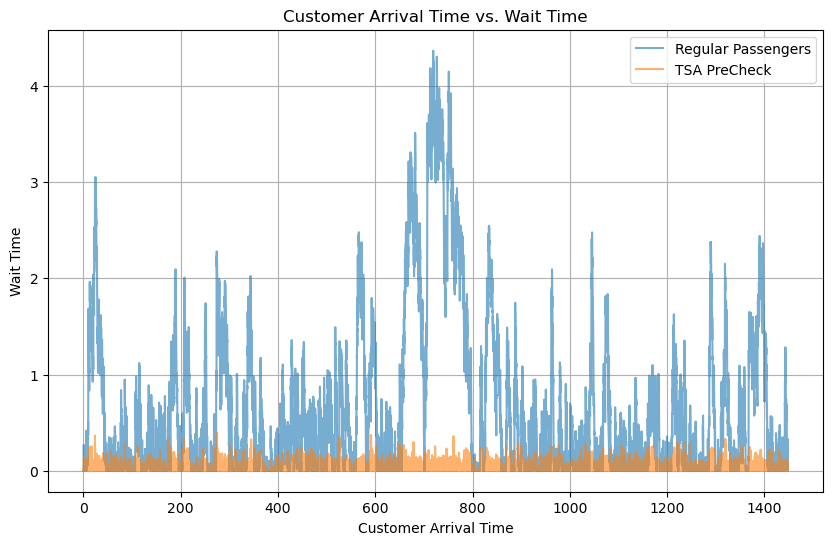

In [1258]:
import matplotlib.pyplot as plt

# Extract data for plotting
y1_wait_times_regular = [wait_times_regular[cid] for cid in wait_times_regular.keys()]
y2_wait_times_precheck = [
    wait_times_precheck[cid] for cid in wait_times_precheck.keys()
]
x1 = [arrival_times_regular[cid] for cid in wait_times_regular.keys()]
x2 = [arrival_times_precheck[cid] for cid in wait_times_precheck.keys()]

plt.figure(figsize=(10, 6))
plt.plot(x1, y1_wait_times_regular, label="Regular Passengers", alpha=0.6)
plt.plot(x2, y2_wait_times_precheck, label="TSA PreCheck", alpha=0.6)
plt.xlabel("Customer Arrival Time")
plt.ylabel("Wait Time")
plt.title("Customer Arrival Time vs. Wait Time")
plt.legend()
plt.grid(True)
plt.show()

In [1259]:
def plot_wait_time_boxplots(wait_times_precheck, wait_times_regular):
    fig, ax = plt.subplots(figsize=(8, 6))

    wait_times_precheck = list(wait_times_precheck.values())
    wait_times_regular = list(wait_times_regular.values())

    plt.boxplot(
        [wait_times_precheck, wait_times_regular],
        tick_labels=[
            f"PreCheck\n(n={len(wait_times_precheck)})",
            f"Regular\n(n={len(wait_times_regular)})",
        ],
        patch_artist=True,
        boxprops=dict(facecolor="white"),
        medianprops=dict(color="black"),
    )

    plt.ylabel("Wait Time (minutes)", fontsize=12)
    plt.title("Comparison of TSA Wait Times", fontsize=14)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

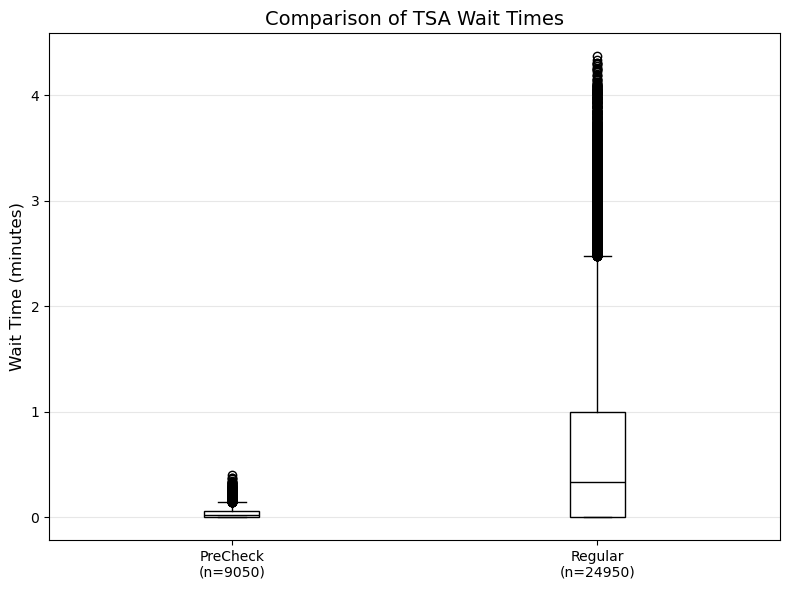

In [1260]:
plot_wait_time_boxplots(wait_times_precheck, wait_times_regular)

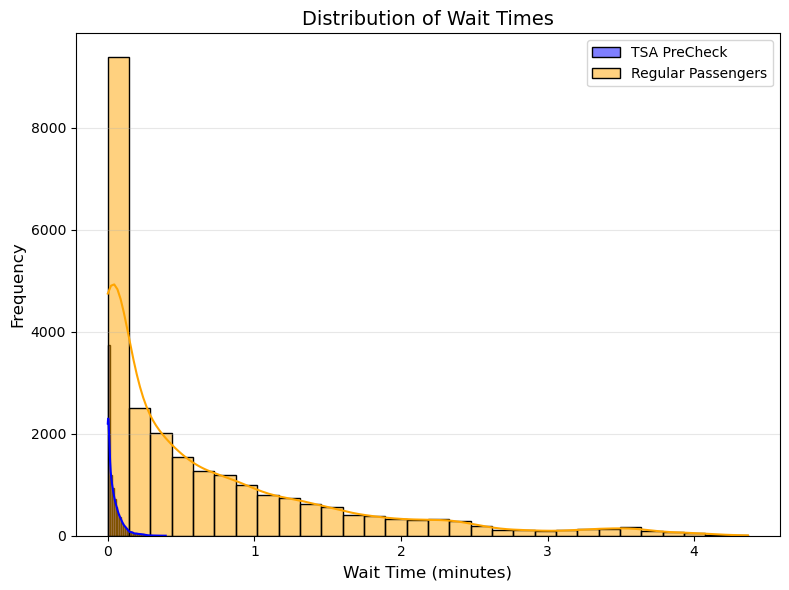

In [1261]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.histplot(
    list(wait_times_precheck.values()),
    bins=30,
    kde=True,
    color="blue",
    label="TSA PreCheck",
)
sns.histplot(
    list(wait_times_regular.values()),
    bins=30,
    kde=True,
    color="orange",
    label="Regular Passengers",
)
plt.xlabel("Wait Time (minutes)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.title("Distribution of Wait Times", fontsize=14)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Multiple Simulations

In [1262]:
num_sims = 100
wait_times_precheck_list = []
wait_times_regular_list = []
arrival_times_precheck_list = []
arrival_times_regular_list = []

for _ in range(num_sims):
    stats_tuple = run_simulation(
        MAX_CUST,
        ARRIVAL_RATE,
        PRECHECK_PROB,
        SERVICE_RATE_PRECHECK,
        SERVICE_RATE_REGULAR,
        NUM_SERVERS,
    )

    (
        wait_times_precheck,
        wait_times_regular,
        arrival_times_precheck,
        arrival_times_regular,
    ) = stats_tuple

    wait_times_precheck_list.extend(list(wait_times_precheck.values()))
    wait_times_regular_list.extend(list(wait_times_regular.values()))
    arrival_times_precheck_list.extend(list(arrival_times_precheck.values()))
    arrival_times_regular_list.extend(list(arrival_times_regular.values()))

In [1263]:
print_results(np.array(wait_times_precheck_list), np.array(wait_times_regular_list))

TSA PreCheck:
  Average wait time: 0.04
  Variance of wait times: 0.00
  Max wait time: 0.81

Regular Passengers:
  Average wait time: 0.54
  Variance of wait times: 0.53
  Max wait time: 8.20


In [1264]:
avg_precheck = np.mean(wait_times_precheck_list)
avg_regular = np.mean(wait_times_regular_list)

weighted_avg = avg_precheck * PRECHECK_PROB + avg_regular * (1 - PRECHECK_PROB)
weighted_avg

0.4074843529682412

In [1265]:
## Optimization

$$
T(s, \mu) = c_ss + (c_{\mu} e^{a \mu}) s + c_wL
$$
- $c_s$: cost of a server per hour
    - Can be interpreted as base pay
- $c_w$: cost of a customer waiting per hour
- $\mu$: service rate of the servers
- $c_{\mu}$: cost of a service rate per server per hour
    - Can be interpreted as bonus pay
- $L$: average number of customers in the system
- $s$: number of servers

The decision variables are $s$ and $\mu$.

In [1266]:
# Cost parameters (per minute)
cs = 30 / 60  # $20/hour → ~$0.33/minute per server
cw = 15 / 60  # $15/hour → $0.25/minute per customer in system
cmu = cs * 0.3

# Arrival & Service Rates (per minute)
lam = 23.6  # customers/minute
mu = np.mean(
    [SERVICE_RATE_REGULAR, SERVICE_RATE_PRECHECK]
)  # average service rate (passengers/minute)

# Optimization constraints
s = 12  # servers
L_s = 0.2

- TSA agent average wage is $28 hour

In [1267]:
rho = lam / (s * mu)
rho

0.8568732014285965

In [1268]:
SERVICE_RATE_REGULAR * 1.5

2.9551499999999997

In [1269]:
import numpy as np
from scipy.special import factorial
from scipy.optimize import minimize


def erlang_c(s, mu, lam):
    rho = lam / (s * mu)
    if rho >= 1:
        return np.inf  # unstable system, infinite queue

    s_int = int(np.floor(s))
    # Sum of terms for states 0 to s-1
    sum_terms = sum((s * rho) ** n / factorial(n) for n in range(s_int))
    numerator = ((s * rho) ** s_int / factorial(s_int)) * (1 / (1 - rho))
    denom = sum_terms + numerator
    P_wait = numerator / denom

    Lq = P_wait * (rho / (1 - rho))
    Ls = Lq + lam / mu
    return Ls


def total_cost(x):
    s, mu = x
    if s < 1 or mu <= 0:
        return 1e10  # Penalize invalid parameters

    Ls = erlang_c(s, mu, lam)
    if Ls == np.inf:
        return 1e10  # Penalize unstable systems

    return cs * s + cw * Ls + cmu * np.exp(0.8 * mu) * s


# Initial guess: servers=5, service rate=1
x0 = [11, 1]
server_bounds = (3, 15)
service_rate_bounds = (0.5, SERVICE_RATE_PRECHECK * 1.33)

bounds = [
    server_bounds,
    service_rate_bounds,
]

from scipy.optimize import basinhopping

result = basinhopping(
    total_cost,
    x0,
    niter=1000,
    T=1.0,
    stepsize=0.5,
    minimizer_kwargs={
        "method": "L-BFGS-B",
        "bounds": bounds,
        "options": {
            "gtol": 1e-8,
            "maxiter": 1000,
            "finite_diff_rel_step": 1e-8,
        },
    },
)

opt_s, opt_mu = result.x
print(f"Optimal number of servers: {opt_s:.2f}")
print(f"Optimal service rate per server: {opt_mu:.2f}")
print(f"Minimum total cost: {result.fun:.2f}")

Optimal number of servers: 12.00
Optimal service rate per server: 2.21
Minimum total cost: 20.45


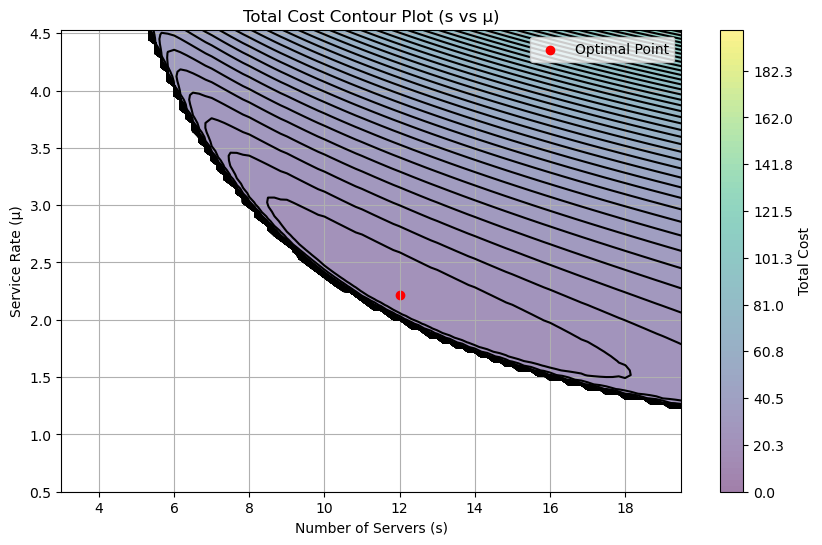

In [1270]:
# Create a grid of s and mu values
s_values = np.linspace(server_bounds[0], server_bounds[1] * 1.3, 100)
mu_values = np.linspace(service_rate_bounds[0], service_rate_bounds[1] * 1.3, 100)

# Compute total cost for each combination
S, MU = np.meshgrid(s_values, mu_values)
Cost = np.zeros_like(S)

for i in range(len(s_values)):
    for j in range(len(mu_values)):
        Cost[j, i] = total_cost([S[j, i], MU[j, i]])

# Plot contour lines
plt.figure(figsize=(10, 6))
contour_levels = np.linspace(0, 200, 80)  # Adjust levels as needed
contour_plot = plt.contour(S, MU, Cost, levels=contour_levels, colors="k")

# Add color gradient (optional)
plt.contourf(S, MU, Cost, levels=contour_levels, cmap="viridis", alpha=0.5)
plt.colorbar(label="Total Cost")

# Mark the optimal point (if known)
optimal_s = result.x[0]
optimal_mu = result.x[1]
plt.scatter(optimal_s, optimal_mu, color="red", label="Optimal Point")

# Labels and title
plt.xlabel("Number of Servers (s)")
plt.ylabel("Service Rate (μ)")
plt.title("Total Cost Contour Plot (s vs μ)")
plt.legend()
plt.grid(True)
plt.show()

## Version 2

- This baseline model is an M/M/c queue, where c is the number of servers.
- The lines are parallel. There is a dedicated server for each line, regular and precheck. this is more akin to CLEAR than precheck (fun fact).
- This model has a closed form solution.

In [1271]:
import random
import heapq
from collections import defaultdict

In [1272]:
# Parameters (units: passengers per minute)
ARRIVAL_RATE_REGULAR = 23.6
PRECHECK_PROB = 0.27
ARRIVAL_RATE_PRECHECK = ARRIVAL_RATE_REGULAR * PRECHECK_PROB

SERVICE_RATE_REGULAR = 1.9701
SERVICE_RATE_PRECHECK = SERVICE_RATE_REGULAR * 1.33

NUM_SERVERS = 12
MAX_CUST = 34000

# Initialize server pools (25% PreCheck, 75% regular)
servers_precheck = [0.0] * int(NUM_SERVERS * 0.2)
servers_regular = [0.0] * int(NUM_SERVERS * 0.8)

In [1273]:
rho = ARRIVAL_RATE_REGULAR / (len(servers_regular) * SERVICE_RATE_REGULAR)
rho

1.3310097062190867

In [1274]:
rho = ARRIVAL_RATE_PRECHECK / (len(servers_precheck) * SERVICE_RATE_PRECHECK)
rho

1.2159224007941278

- Right off the bat, the stability condition is not satisfied with the parallel system. This means the priority queue version is better than the parallel system approach.
- This harkens back to the class poll on whether we should divide up resources or not. The answer in class wa no.

In [1275]:
# Parameters (units: passengers per minute)
ARRIVAL_RATE_REGULAR = 23.6
PRECHECK_PROB = 0.05
ARRIVAL_RATE_PRECHECK = ARRIVAL_RATE_REGULAR * PRECHECK_PROB

SERVICE_RATE_REGULAR = 1.9701
SERVICE_RATE_PRECHECK = SERVICE_RATE_REGULAR * 1.33

NUM_SERVERS = 13
MAX_CUST = 34000

# Initialize server pools (25% PreCheck, 75% regular)
servers_precheck = [0.0] * 1
servers_regular = [0.0] * 12

In [1276]:
rho = ARRIVAL_RATE_REGULAR / (len(servers_regular) * SERVICE_RATE_REGULAR)
rho

0.998257279664315

In [1277]:
rho = ARRIVAL_RATE_PRECHECK / (len(servers_precheck) * SERVICE_RATE_PRECHECK)
rho

0.4503416299237511

In [1278]:
# Queues for each passenger type
queue_precheck = []
queue_regular = []

# Event queue: (event_time, event_type, customer_id, queue_type)
event_queue = []

# Statistics - now using dictionaries to track by customer ID
wait_times_precheck = {}
wait_times_regular = {}
arrival_times_precheck = {}
arrival_times_regular = {}

# Customer ID counter
customer_id = 0

In [1279]:
def schedule_arrival(queue_type, current_time):
    """Schedule the next arrival event for the given queue type."""
    global customer_id
    arrival_rate = (
        ARRIVAL_RATE_PRECHECK if queue_type == "precheck" else ARRIVAL_RATE_REGULAR
    )
    inter_arrival = random.expovariate(arrival_rate)
    arrival_time = current_time + inter_arrival
    heapq.heappush(event_queue, (arrival_time, "arrival", customer_id, queue_type))

    # Record arrival time
    if queue_type == "precheck":
        arrival_times_precheck[customer_id] = arrival_time
    else:
        arrival_times_regular[customer_id] = arrival_time

    customer_id += 1

In [1280]:
def assign_server(servers, current_time, service_rate):
    """Assign a customer to an available server or return None if all busy."""
    for i, free_time in enumerate(servers):
        if free_time <= current_time:
            service_time = random.expovariate(service_rate)
            servers[i] = current_time + service_time
            return current_time + service_time  # return departure time
    return None

In [1281]:
def process_arrival(current_time, cid, line):
    """Process an arrival event."""
    # Schedule next arrival for this line
    schedule_arrival(line, current_time)

    if line == "precheck":
        servers = servers_precheck
        service_rate = SERVICE_RATE_PRECHECK
        wait_dict = wait_times_precheck
        queue = queue_precheck
    else:
        servers = servers_regular
        service_rate = SERVICE_RATE_REGULAR
        wait_dict = wait_times_regular
        queue = queue_regular

    departure_time = assign_server(servers, current_time, service_rate)

    if departure_time is not None:
        # Served immediately, wait time = 0
        wait_dict[cid] = 0.0
        heapq.heappush(event_queue, (departure_time, "departure", cid, line))
    else:
        # Queue the customer (store arrival time for wait time calculation later)
        queue.append((cid, current_time))

In [1282]:
def process_departure(current_time, cid, line):
    """Process a departure event."""
    if line == "precheck":
        servers = servers_precheck
        service_rate = SERVICE_RATE_PRECHECK
        wait_dict = wait_times_precheck
        queue = queue_precheck
    else:
        servers = servers_regular
        service_rate = SERVICE_RATE_REGULAR
        wait_dict = wait_times_regular
        queue = queue_regular

    # Check if someone is waiting in this queue
    if queue:
        next_cid, arrival_time = queue.pop(0)
        wait_time = current_time - arrival_time
        wait_dict[next_cid] = wait_time
        departure_time = assign_server(servers, current_time, service_rate)
        # departure_time should never be None here since a server just freed
        heapq.heappush(event_queue, (departure_time, "departure", next_cid, line))

In [1283]:
def run_simulation():
    """Run the main simulation loop."""
    global customer_id

    # Schedule first arrivals for both lines
    schedule_arrival("precheck", 0.0)
    schedule_arrival("regular", 0.0)

    while event_queue and customer_id < MAX_CUST:
        current_time, event_type, cid, line = heapq.heappop(event_queue)

        if event_type == "arrival":
            process_arrival(current_time, cid, line)
        elif event_type == "departure":
            process_departure(current_time, cid, line)

    # Return all statistics for analysis
    return {
        "wait_precheck": wait_times_precheck,
        "wait_regular": wait_times_regular,
        "arrival_precheck": arrival_times_precheck,
        "arrival_regular": arrival_times_regular,
    }


# Run the simulation
results = run_simulation()


# Calculate and print summary statistics
def print_summary(wait_times, arrival_times, name):
    if wait_times:
        avg_wait = sum(wait_times.values()) / len(wait_times)
        print(f"\n{name}:")
        print(f"  Customers served: {len(wait_times)}")
        print(f"  Average wait time: {avg_wait:.3f} minutes")
        print(f"  Max wait time: {max(wait_times.values()):.3f} minutes")
    else:
        print(f"\n{name}: No customers served")


print_summary(results["wait_precheck"], results["arrival_precheck"], "PreCheck")
print_summary(results["wait_regular"], results["arrival_regular"], "Regular")


PreCheck:
  Customers served: 1610
  Average wait time: 0.330 minutes
  Max wait time: 3.600 minutes

Regular:
  Customers served: 32162
  Average wait time: 3.777 minutes
  Max wait time: 9.863 minutes


In [1284]:
avg_precheck = np.mean(list(results["wait_precheck"].values()))
avg_regular = np.mean(list(results["wait_regular"].values()))

weighted_avg = avg_precheck * PRECHECK_PROB + avg_regular * (1 - PRECHECK_PROB)
weighted_avg

3.6051095362367893

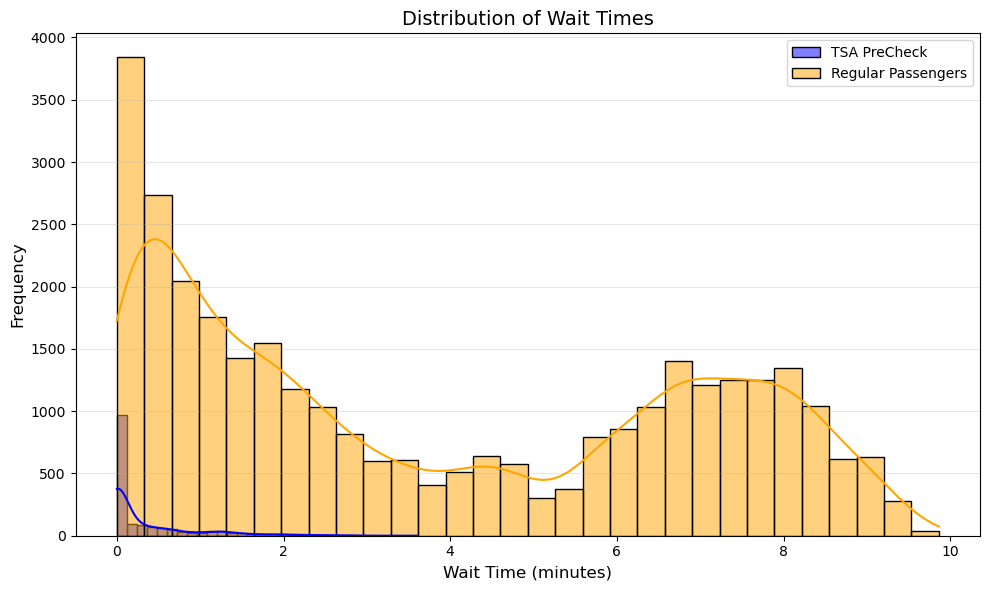

In [1285]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(
    list(results["wait_precheck"].values()),
    bins=30,
    kde=True,
    color="blue",
    label="TSA PreCheck",
)
sns.histplot(
    list(results["wait_regular"].values()),
    bins=30,
    kde=True,
    color="orange",
    label="Regular Passengers",
)
plt.xlabel("Wait Time (minutes)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.title("Distribution of Wait Times", fontsize=14)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

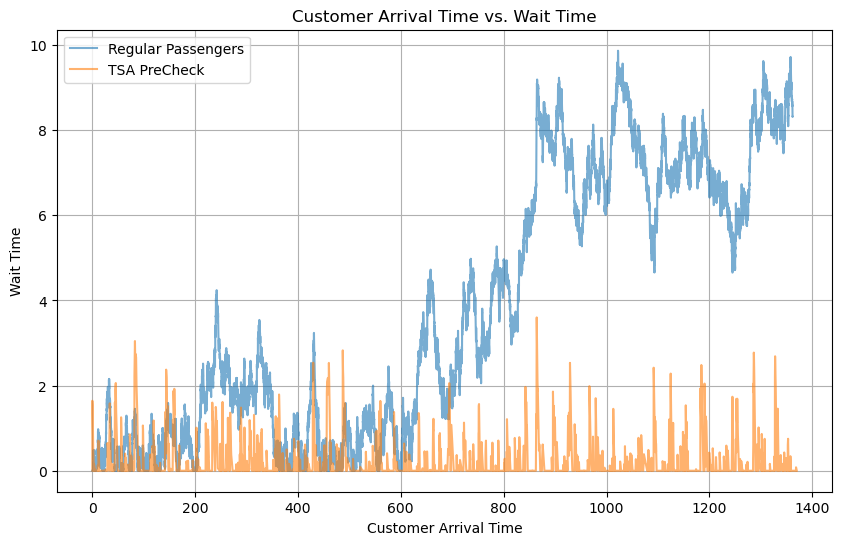

In [1286]:
import matplotlib.pyplot as plt

# Extract data for plotting
y1_wait_times_regular = list(results["wait_regular"].values())
y2_wait_times_precheck = list(results["wait_precheck"].values())
x1 = [results["arrival_regular"][cid] for cid in results["wait_regular"].keys()]
x2 = [results["arrival_precheck"][cid] for cid in results["wait_precheck"].keys()]

plt.figure(figsize=(10, 6))
plt.plot(x1, y1_wait_times_regular, label="Regular Passengers", alpha=0.6)
plt.plot(x2, y2_wait_times_precheck, label="TSA PreCheck", alpha=0.6)
plt.xlabel("Customer Arrival Time")
plt.ylabel("Wait Time")
plt.title("Customer Arrival Time vs. Wait Time")
plt.legend()
plt.grid(True)
plt.show()

In [1287]:
# Cost parameters (per minute)
cs = 30 / 60  # $20/hour → ~$0.33/minute per server
cw = 15 / 60  # $15/hour → $0.25/minute per customer in system
cmu = cs * 0.3

# Arrival & Service Rates (per minute)
lam = 23.6  # customers/minute
mu = np.mean(
    [SERVICE_RATE_REGULAR, SERVICE_RATE_PRECHECK]
)  # average service rate (passengers/minute)

# Optimization constraints
s = 13  # servers
L_s = weighted_avg

- TSA agent average wage is $28 hour

In [1288]:
rho = lam / (s * mu)
rho

0.7909598782417814

In [1289]:
SERVICE_RATE_REGULAR * 1.5

2.9551499999999997

## Sensitivity Analysis

In [1290]:
def record_wait_time(
    wait_time, is_precheck, wait_times_precheck, wait_times_regular, cid
):
    """Record wait time in appropriate list"""
    if is_precheck:
        wait_times_precheck[cid] = wait_time
    else:
        wait_times_regular[cid] = wait_time

In [1291]:
def get_service_time(is_precheck, service_rate_precheck, service_rate_regular):
    """Generate service time based on customer type"""
    service_rate = service_rate_precheck if is_precheck else service_rate_regular
    return random.expovariate(service_rate)

In [1292]:
def find_available_servers(servers_busy_until, current_time):
    """Find all available servers"""
    return [i for i, t in enumerate(servers_busy_until) if t <= current_time]

In [1293]:
def assign_to_server_or_queue(
    servers_busy_until,
    current_time,
    is_precheck,
    service_rate_precheck,
    service_rate_regular,
    event_queue,
    cid,
    waiting_queue,
    priority,
    wait_times_precheck,
    wait_times_regular,
):
    """Assign customer to available server or add to waiting queue"""
    available_servers = find_available_servers(servers_busy_until, current_time)

    if available_servers:
        server = available_servers[0]
        service_time = get_service_time(
            is_precheck, service_rate_precheck, service_rate_regular
        )
        servers_busy_until[server] = current_time + service_time

        record_wait_time(0.0, is_precheck, wait_times_precheck, wait_times_regular, cid)

        heapq.heappush(event_queue, (current_time + service_time, "departure", cid))
    else:
        heapq.heappush(waiting_queue, (priority, current_time, cid, is_precheck))

In [1294]:
def handle_arrival_event(
    event_queue,
    current_time,
    cid,
    customer_id,
    arrival_rate,
    precheck_probability,
    servers_busy_until,
    service_rate_precheck,
    service_rate_regular,
    waiting_queue,
    wait_times_precheck,
    wait_times_regular,
    arrival_times_precheck,
    arrival_times_regular,
):
    """Process a customer arrival event"""

    # Schedule next arrival
    inter_arrival = random.expovariate(arrival_rate)
    heapq.heappush(event_queue, (current_time + inter_arrival, "arrival", customer_id))

    # Determine if PreCheck or regular
    is_precheck = random.random() < precheck_probability
    priority = 0 if is_precheck else 1

    # Record arrival time
    if is_precheck:
        arrival_times_precheck[cid] = current_time
    else:
        arrival_times_regular[cid] = current_time

    # Try to assign to server
    assign_to_server_or_queue(
        servers_busy_until,
        current_time,
        is_precheck,
        service_rate_precheck,
        service_rate_regular,
        event_queue,
        cid,
        waiting_queue,
        priority,
        wait_times_precheck,
        wait_times_regular,
    )

    return customer_id + 1

In [1295]:
def handle_departure_event(
    event_queue,
    current_time,
    servers_busy_until,
    waiting_queue,
    service_rate_precheck,
    service_rate_regular,
    wait_times_precheck,
    wait_times_regular,
):
    """Process a server departure event"""
    available_servers = find_available_servers(servers_busy_until, current_time)

    for server in available_servers:
        if waiting_queue:
            priority, arrival_time, queued_cid, is_precheck = heapq.heappop(
                waiting_queue
            )
            service_time = get_service_time(
                is_precheck, service_rate_precheck, service_rate_regular
            )
            servers_busy_until[server] = current_time + service_time

            wait_time = current_time - arrival_time
            record_wait_time(
                wait_time,
                is_precheck,
                wait_times_precheck,
                wait_times_regular,
                queued_cid,
            )

            heapq.heappush(
                event_queue, (current_time + service_time, "departure", queued_cid)
            )

In [1296]:
def run_simulation(
    max_cust,
    arrival_rate,
    precheck_probability,
    service_rate_precheck,
    service_rate_regular,
    num_servers,
):
    """Main simulation function"""
    # System State
    event_queue = []
    waiting_queue = []
    servers_busy_until = [0.0] * num_servers
    wait_times_precheck = dict()
    wait_times_regular = dict()

    # For plotting layer
    arrival_times_precheck = dict()
    arrival_times_regular = dict()

    # Schedule first arrival
    heapq.heappush(event_queue, (0.0, "arrival", 0))
    customer_id = 1

    # Main event loop
    while event_queue:
        event_time, event_type, cid = heapq.heappop(event_queue)
        current_time = event_time

        if event_type == "arrival":
            if customer_id <= MAX_CUST:
                # Handle arrival event
                customer_id = handle_arrival_event(
                    event_queue,
                    current_time,
                    cid,
                    customer_id,
                    arrival_rate,
                    precheck_probability,
                    servers_busy_until,
                    service_rate_precheck,
                    service_rate_regular,
                    waiting_queue,
                    wait_times_precheck,
                    wait_times_regular,
                    arrival_times_precheck,
                    arrival_times_regular,
                )
        elif event_type == "departure":
            handle_departure_event(
                event_queue,
                current_time,
                servers_busy_until,
                waiting_queue,
                service_rate_precheck,
                service_rate_regular,
                wait_times_precheck,
                wait_times_regular,
            )

    return (
        wait_times_precheck,
        wait_times_regular,
        arrival_times_precheck,
        arrival_times_regular,
    )

### Arrival Rate

In [1300]:
# units are passengers per minute
arrival_wait_candidates = np.linspace(10, 40, 100)

In [1301]:
stats_dict = {}

for arrival_wait in arrival_wait_candidates:
    stats_tuple = run_simulation(
        MAX_CUST,
        arrival_wait,
        PRECHECK_PROB,
        SERVICE_RATE_PRECHECK,
        SERVICE_RATE_REGULAR,
        NUM_SERVERS,
    )

    # Unpack the results
    (
        wait_times_precheck,
        wait_times_regular,
        arrival_times_precheck,
        arrival_times_regular,
    ) = stats_tuple

    avg_precheck = np.mean(list(wait_times_precheck.values()))
    avg_regular = np.mean(list(wait_times_regular.values()))
    max_precheck = max(wait_times_precheck.values())
    max_regular = max(wait_times_regular.values())

    stats_dict[arrival_wait] = {
        "avg_precheck": avg_precheck,
        "avg_regular": avg_regular,
        "max_precheck": max_precheck,
        "max_regular": max_regular,
    }

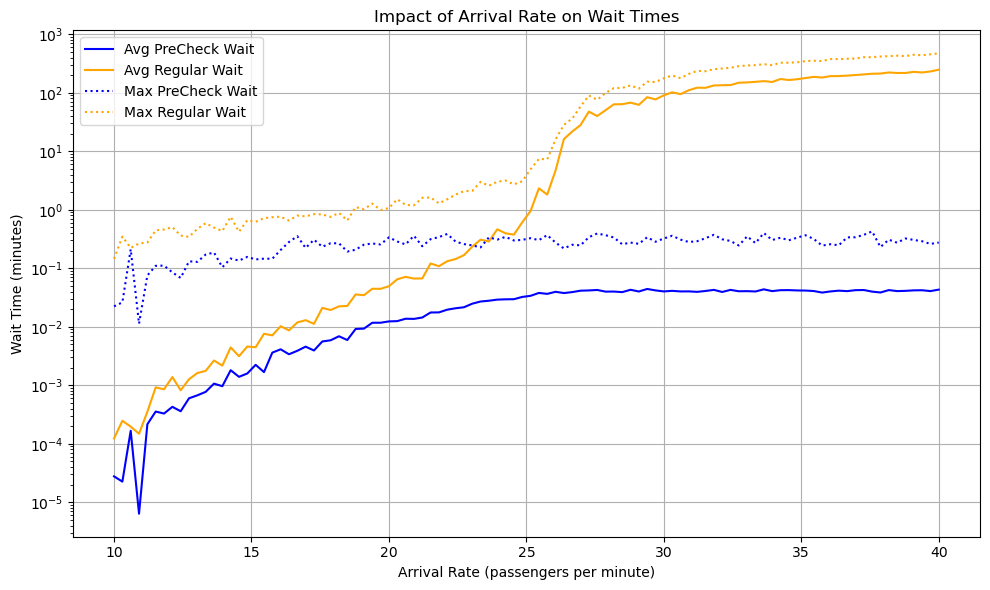

In [1302]:
fig, ax = plt.subplots(figsize=(10, 6))

arrival_waits = list(stats_dict.keys())
avg_precheck_values = [stat["avg_precheck"] for stat in stats_dict.values()]
avg_regular_values = [stat["avg_regular"] for stat in stats_dict.values()]
max_precheck_values = [stat["max_precheck"] for stat in stats_dict.values()]
max_regular_values = [stat["max_regular"] for stat in stats_dict.values()]

ax.plot(
    arrival_waits,
    avg_precheck_values,
    label="Avg PreCheck Wait",
    color="blue",
)
ax.plot(
    arrival_waits,
    avg_regular_values,
    label="Avg Regular Wait",
    color="orange",
)
ax.plot(
    arrival_waits,
    max_precheck_values,
    label="Max PreCheck Wait",
    linestyle=":",
    color="blue",
)
ax.plot(
    arrival_waits,
    max_regular_values,
    label="Max Regular Wait",
    linestyle=":",
    color="orange",
)

ax.set_xlabel("Arrival Rate (passengers per minute)")
ax.set_ylabel("Wait Time (minutes)")
# set to log scale
ax.set_yscale("log")
ax.set_title("Impact of Arrival Rate on Wait Times")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

### Services Rates

In [1309]:
service_rate_regular_candidates = np.linspace(
    SERVICE_RATE_REGULAR * 0.5, SERVICE_RATE_REGULAR * 1.5, 100
)
service_rate_precheck_candidates = service_rate_regular_candidates * 1.33

In [1310]:
stats_dict = {}

for service_rate_regular, service_rate_precheck in zip(
    service_rate_regular_candidates, service_rate_precheck_candidates
):
    stats_tuple = run_simulation(
        MAX_CUST,
        ARRIVAL_RATE,
        PRECHECK_PROB,
        service_rate_precheck,
        service_rate_regular,
        NUM_SERVERS,
    )

    # Unpack the results
    (
        wait_times_precheck,
        wait_times_regular,
        arrival_times_precheck,
        arrival_times_regular,
    ) = stats_tuple

    avg_precheck = np.mean(list(wait_times_precheck.values()))
    avg_regular = np.mean(list(wait_times_regular.values()))
    max_precheck = max(wait_times_precheck.values())
    max_regular = max(wait_times_regular.values())

    stats_dict[service_rate_regular] = {
        "avg_precheck": avg_precheck,
        "avg_regular": avg_regular,
        "max_precheck": max_precheck,
        "max_regular": max_regular,
    }

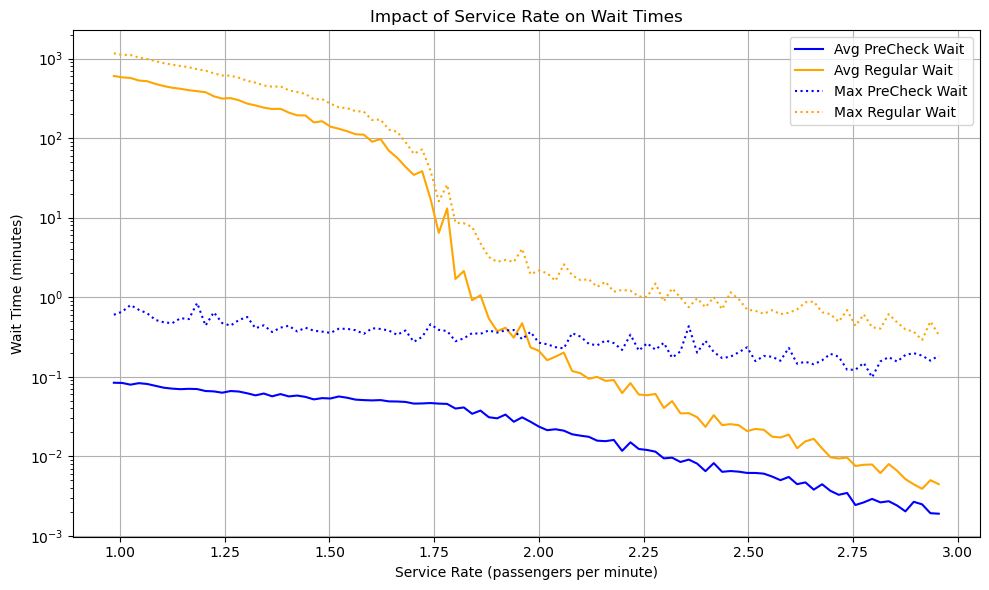

In [1314]:
fig, ax = plt.subplots(figsize=(10, 6))

service_rate_regular = list(stats_dict.keys())
avg_precheck_values = [stat["avg_precheck"] for stat in stats_dict.values()]
avg_regular_values = [stat["avg_regular"] for stat in stats_dict.values()]
max_precheck_values = [stat["max_precheck"] for stat in stats_dict.values()]
max_regular_values = [stat["max_regular"] for stat in stats_dict.values()]

ax.plot(
    service_rate_regular,
    avg_precheck_values,
    label="Avg PreCheck Wait",
    color="blue",
)
ax.plot(
    service_rate_regular,
    avg_regular_values,
    label="Avg Regular Wait",
    color="orange",
)
ax.plot(
    service_rate_regular,
    max_precheck_values,
    label="Max PreCheck Wait",
    linestyle=":",
    color="blue",
)
ax.plot(
    service_rate_regular,
    max_regular_values,
    label="Max Regular Wait",
    linestyle=":",
    color="orange",
)
ax.set_xlabel("Service Rate (passengers per minute)")
ax.set_ylabel("Wait Time (minutes)")
ax.set_title("Impact of Service Rate on Wait Times")
ax.legend()
ax.set_yscale("log")
ax.grid(True)
plt.tight_layout()
plt.show()

### Number of Servers

In [1317]:
num_server_candidates = np.arange(3, 24)

stats_dict = {}

for num_servers in num_server_candidates:
    stats_tuple = run_simulation(
        MAX_CUST,
        ARRIVAL_RATE,
        PRECHECK_PROB,
        SERVICE_RATE_PRECHECK,
        SERVICE_RATE_REGULAR,
        num_servers,
    )

    # Unpack the results
    (
        wait_times_precheck,
        wait_times_regular,
        arrival_times_precheck,
        arrival_times_regular,
    ) = stats_tuple

    avg_precheck = np.mean(list(wait_times_precheck.values()))
    avg_regular = np.mean(list(wait_times_regular.values()))
    max_precheck = max(wait_times_precheck.values())
    max_regular = max(wait_times_regular.values())

    stats_dict[num_servers] = {
        "avg_precheck": avg_precheck,
        "avg_regular": avg_regular,
        "max_precheck": max_precheck,
        "max_regular": max_regular,
    }

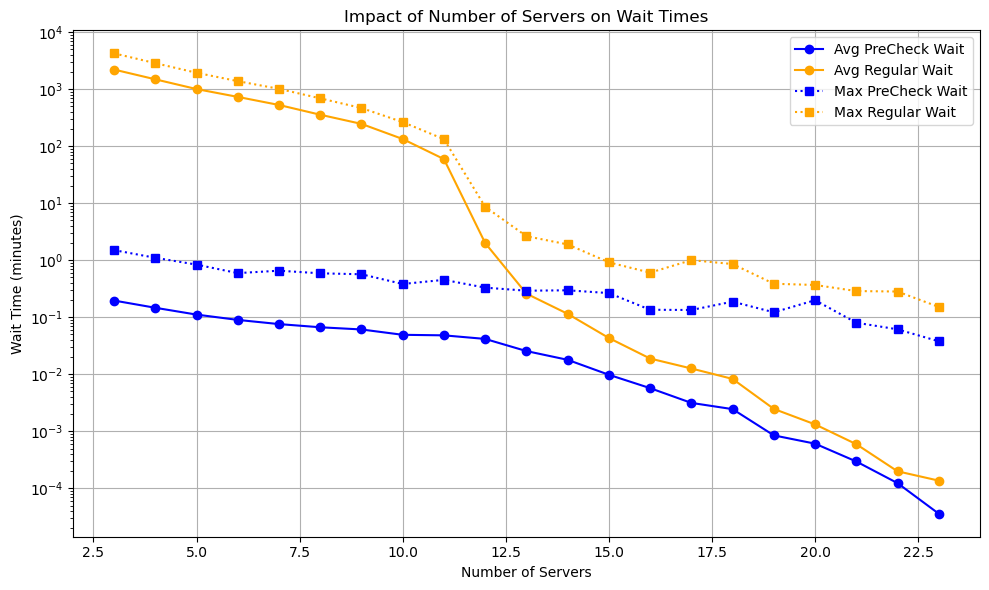

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

num_server_candidates = list(stats_dict.keys())
avg_precheck_values = [stat["avg_precheck"] for stat in stats_dict.values()]
avg_regular_values = [stat["avg_regular"] for stat in stats_dict.values()]
max_precheck_values = [stat["max_precheck"] for stat in stats_dict.values()]
max_regular_values = [stat["max_regular"] for stat in stats_dict.values()]

ax.plot(
    num_server_candidates,
    avg_precheck_values,
    label="Avg PreCheck Wait",
    color="blue",
    marker="o",  # Add markers for better visibility
)
ax.plot(
    num_server_candidates,
    avg_regular_values,
    label="Avg Regular Wait",
    color="orange",
    marker="o",  # Add markers for better visibility
)
ax.plot(
    num_server_candidates,
    max_precheck_values,
    label="Max PreCheck Wait",
    linestyle=":",
    color="blue",
    marker="s",
)
ax.plot(
    num_server_candidates,
    max_regular_values,
    label="Max Regular Wait",
    linestyle=":",
    color="orange",
    marker="s",
)
ax.set_xlabel("Number of Servers")
ax.set_ylabel("Wait Time (minutes)")
ax.set_title("Impact of Number of Servers on Wait Times")
ax.legend()
ax.set_yscale("log")
ax.grid(True)
plt.tight_layout()
plt.show()